In [13]:
import torch
print("--- PYTORCH CHECK ---")
print(f"Version: {torch.__version__}")
is_available = torch.cuda.is_available()
print(f"GPU Available: {is_available}")

if is_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
# Expected: GPU Available: True and the name of your GPU.


--- PYTORCH CHECK ---
Version: 2.6.0+cu124
GPU Available: True
GPU Name: NVIDIA GeForce MX150


In [14]:
import cv2
print("--- OPENCV CHECK (cv2) ---")
print(f"Version: {cv2.__version__}")

# Check if a core component loads successfully
try:
    # A simple check to see if the library's features are accessible
    print(f"Module Status: Loaded successfully.")
except Exception as e:
    print(f"Status: FAIL - Crash: {e}")

# EXPECTED SUCCESS: Version 4.8.0.74


--- OPENCV CHECK (cv2) ---
Version: 4.11.0
Module Status: Loaded successfully.


In [15]:
import tensorflow as tf
print("--- TENSORFLOW CHECK ---")
print(f"Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

# Expected: Version 2.10.0 and a list showing your physical device.


--- TENSORFLOW CHECK ---
Version: 2.10.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
pip list show


Package                                  Version
---------------------------------------- ------------
absl-py                                  2.3.1
annotated-doc                            0.0.4
annotated-types                          0.7.0
anyio                                    4.12.0
arabic-reshaper                          3.0.0
argon2-cffi                              25.1.0
argon2-cffi-bindings                     25.1.0
arrow                                    1.4.0
asttokens                                3.0.0
astunparse                               1.6.3
async-lru                                2.0.5
attrs                                    25.4.0
babel                                    2.17.0
backoff                                  2.2.1
bcrypt                                   5.0.0
beautifulsoup4                           4.14.2
bleach                                   6.2.0
blinker                                  1.9.0
build                                    1.3.

In [17]:
import tensorflow as tf

# Check if the device is found and accessible
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Access the properties of the first detected device (GPU:0)
        details = tf.config.experimental.get_device_details(gpus[0])
        # The friendly name is usually stored here
        name = details.get('device_name', 'Name retrieval failed.') 
        print(f"--- DETAILED TENSORFLOW GPU CHECK ---")
        print(f"✅ Device Found: {gpus[0].name}")
        print(f"✅ **GPU NAME**: {name}")
    except Exception:
        # Fallback if the experimental API is not stable
        print("✅ GPU Detected. Name retrieval failed (API instability).")
        print(f"Path: {gpus[0].name}")
else:
    print("❌ No GPU found by TensorFlow.")


--- DETAILED TENSORFLOW GPU CHECK ---
✅ Device Found: /physical_device:GPU:0
✅ **GPU NAME**: NVIDIA GeForce MX150


Removing the .DS_Store(hidden files) files in the training dataset

In [18]:
import mediapipe as mp
print("--- MEDIAPIPE CHECK ---")

try:
    # Attempt to initialize a core module (Hands) that relies on Protobuf
    mp_hands = mp.solutions.hands
    print("Status: SUCCESS - Module loaded and initialized.")
except Exception as e:
    print(f"Status: FAIL - Crash: {e}")
# EXPECTED SUCCESS: Status: SUCCESS - Module loaded and initialized.


--- MEDIAPIPE CHECK ---
Status: SUCCESS - Module loaded and initialized.


In [19]:
import tensorflow as tf
print("--- TENSORFLOW CHECK ---")
print(f"Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

# EXPECTED SUCCESS: Version 2.10.0 and a list of physical devices (e.g., '[PhysicalDevice...]')


--- TENSORFLOW CHECK ---
Version: 2.10.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
import tensorflow as tf
import os

print("Running DLL Check...")

# 1. Check if CUDA is in Path
cuda_path = os.environ.get('CUDA_PATH')
print(f"CUDA_PATH: {cuda_path}")

# 2. Try to load the GPU
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"✅ SUCCESS! Detected: {gpus[0].name}")
else:
    print("❌ FAILURE: No GPU detected.")
    print("Possible missing files in 'C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.2\\bin':")
    print("- cudart64_110.dll (From CUDA Toolkit)")
    print("- cudnn64_8.dll    (From cuDNN)")
    print("- zlibwapi.dll     (The secret file)")


Running DLL Check...
CUDA_PATH: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2
✅ SUCCESS! Detected: /physical_device:GPU:0


## Configuration & Hyperparameters
All major paths, model parameters, and training settings are centralized here so you can easily modify them without hunting through the code.

In [ ]:
# --- PATHS ---
TRAIN_DATASET_DIR = r"m:\Term 10\Grad\Letters Datasets\Asl_Sign_Data\asl_alphabet_train"
TEST_DATASET_DIR  = r       "M:\Term 10\Grad\Letters Datasets\Asl_Sign_Data\asl_alphabet_test"
MODEL_SAVE_PATH   = "sign_language_model_MobileNetV2.h5"

# --- IMAGE & BATCH SETTINGS ---
IMG_SIZE   = 128 
BATCH_SIZE = 32

# --- MODEL ARCHITECTURE ---
DENSE_UNITS  = 256
DROPOUT_RATE = 0.3

# --- TRAINING SETTINGS ---
INITIAL_EPOCHS      = 5
FINETUNE_EPOCHS     = 10
FINETUNE_LEARN_RATE = 1e-4


In [22]:
import os

dataset_dir = TRAIN_DATASET_DIR

# Traverse all subdirectories and remove .DS_Store files
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file == ".DS_Store":
            file_path = os.path.join(root, file)
            os.remove(file_path)
            print(f"Removed: {file_path}")

print("All .DS_Store files removed successfully!")


All .DS_Store files removed successfully!


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import cv2


Data Visualisation

Classes: ['A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'nothing', 'O', 'P', 'Q', 'R', 'S', 'space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


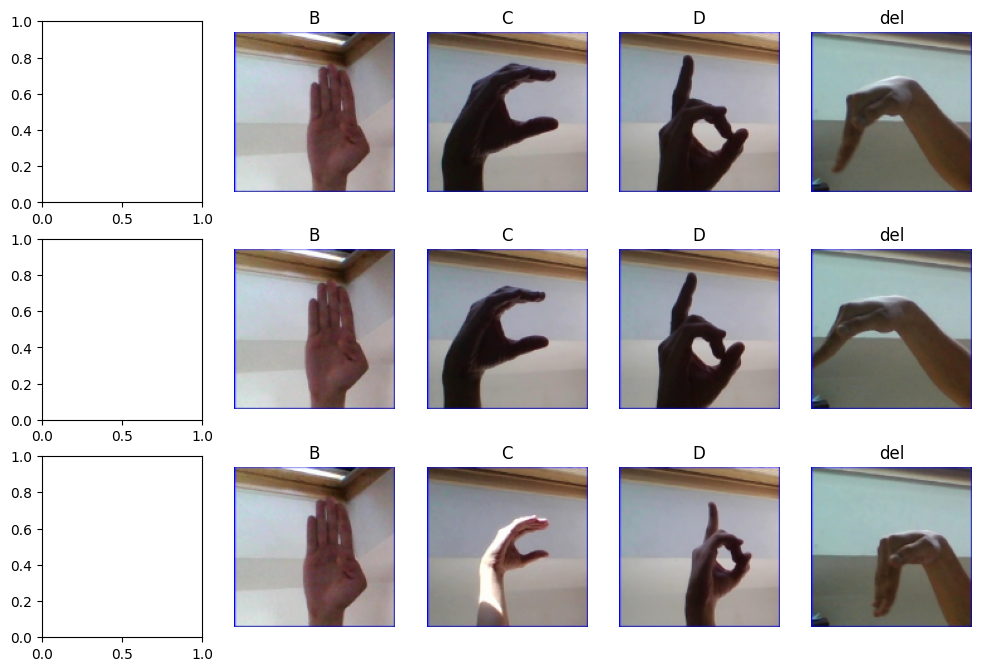

In [24]:
dataset_dir = TRAIN_DATASET_DIR

classes = os.listdir(dataset_dir)
print(f"Classes: {classes}")

# Visualize some images
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for i, label in enumerate(classes[:5]):  # Show first 5 classes
    class_dir = os.path.join(dataset_dir, label)
    img_files = os.listdir(class_dir)[:3]  # Show 3 images per class

    for j, img_name in enumerate(img_files):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, (128, 128))
        
        axes[j, i].imshow(img)
        axes[j, i].axis("off")
        axes[j, i].set_title(label)

plt.show()


Data Pre-processing

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size

# Data generators
# We are using this approach to make it less computaionally extensive as the data consists of 87,000 images appx,
# loading all the images as generally done and then label encoding them will be CPU extensive task. 

train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Splitting data into train (80%) and val (20%)
)

# Train & validation generators (load images directly from disk)
train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print("Class labels:", train_generator.class_indices)


Found 66519 images belonging to 29 classes.
Found 16629 images belonging to 29 classes.
Class labels: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


Defining the MobileNet V2 Model

In [26]:
base_model = MobileNetV2(
    weights="imagenet", 
    include_top=False, 
    input_shape=(128, 128, 3)
)

base_model.trainable = False  # Freezing all layers initially as this is an intial training

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(DENSE_UNITS, activation="relu")(x)
x = Dropout(DROPOUT_RATE)(x)
output_layer = Dense(len(train_generator.class_indices), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Initial training on the dataset

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS 
)


Epoch 1/5
  25/2079 [..............................] - ETA: 1:00:44 - loss: 3.3207 - accuracy: 0.1462

ResourceExhaustedError: Graph execution error:

2 root error(s) found.
  (0) RESOURCE_EXHAUSTED:  MemoryError: Unable to allocate 6.00 MiB for an array with shape (32, 128, 128, 3) and data type float32
Traceback (most recent call last):

  File "c:\Users\adelg\AppData\Local\Programs\Python\Python39\lib\site-packages\tensorflow\python\ops\script_ops.py", line 271, in __call__
    ret = func(*args)

  File "c:\Users\adelg\AppData\Local\Programs\Python\Python39\lib\site-packages\tensorflow\python\autograph\impl\api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "c:\Users\adelg\AppData\Local\Programs\Python\Python39\lib\site-packages\tensorflow\python\data\ops\dataset_ops.py", line 1035, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "c:\Users\adelg\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\engine\data_adapter.py", line 904, in wrapped_generator
    yield self._standardize_batch(data)

  File "c:\Users\ade

Fine Tuning the model further

In [ ]:
for layer in base_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

# Recompile with a lower learning rate to avoid overfitting
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=FINETUNE_LEARN_RATE),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINETUNE_EPOCHS
)


In [ ]:
model.save(MODEL_SAVE_PATH)
print("Model saved successfully!")


Model Testing

In [ ]:
# Load the trained model
model = tf.keras.models.load_model(MODEL_SAVE_PATH)

print("Model loaded successfully!")


In [ ]:
# Generate class labels dynamically based on alphabetical folder sorting
class_labels = {v: k for k, v in train_generator.class_indices.items()}
print(f"Dynamically generated class labels: {class_labels}")


In [ ]:
test_folder = TEST_DATASET_DIR

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_folder,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False # Very important for evaluation to match predictions with true labels
)

print(f"Loaded test images from {test_folder}")


In [ ]:
# Get model predictions
predictions = model.predict(test_generator)

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Print first 10 predictions as a sample
filenames = test_generator.filenames
for i in range(min(10, len(filenames))):
    pred_label = class_labels[predicted_classes[i]]
    true_label = class_labels[true_classes[i]]
    print(f"Image: {filenames[i]} → Predicted as: {pred_label} (True: {true_label})")


Test Accuracy

In [ ]:
correct = np.sum(predicted_classes == true_classes)
accuracy = (correct / len(true_classes)) * 100

print(f"Test Accuracy: {accuracy:.2f}%")


Results Visualisation

In [ ]:
history_dict = history.history

# Plot Accuracy Graph
plt.figure(figsize=(10, 5))
plt.plot(history_dict["accuracy"], label="Training Accuracy", marker="o", color="orange")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy", marker="o", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss Graph
plt.figure(figsize=(10, 5))
plt.plot(history_dict["loss"], label="Training Loss", marker="o", color="red")
plt.plot(history_dict["val_loss"], label="Validation Loss", marker="o", color="blue")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

label_names = [class_labels[i] for i in range(len(class_labels))]
cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(len(class_labels))))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for ASL Sign Recognition")
plt.show()


Predicting the Signs from camera feed

- The approach is to use mediapipe to find the center of the hand, make a box/ frame around it, pass the image inside of frame to the trained model.

- Since MobileNet V2 is convolutional neural network, it would not give accurate results on real life data

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
    # Note: We are reusing the dynamically generated `class_labels` dictionary from earlier.

# Load trained MobileNetV2 model
mobilenet_model = tf.keras.models.load_model(MODEL_SAVE_PATH)


mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.7)

cap = cv2.VideoCapture(0)

#Bounding Box Adjustments
HEIGHT_EXPAND = 220
WIDTH_EXPAND = 150

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # Get bounding box coordinates
            x_min = min([lm.x for lm in hand_landmarks.landmark]) * frame.shape[1]
            y_min = min([lm.y for lm in hand_landmarks.landmark]) * frame.shape[0]
            x_max = max([lm.x for lm in hand_landmarks.landmark]) * frame.shape[1]
            y_max = max([lm.y for lm in hand_landmarks.landmark]) * frame.shape[0]

            x_min = max(0, int(x_min - WIDTH_EXPAND))   
            y_min = max(0, int(y_min - HEIGHT_EXPAND)) 
            x_max = min(frame.shape[1], int(x_max + WIDTH_EXPAND))  
            y_max = min(frame.shape[0], int(y_max + HEIGHT_EXPAND)) 

            # Crop the hand region
            hand_crop = frame[y_min:y_max, x_min:x_max]

            # Resize to (128x128) for MobileNetV2
            if hand_crop.shape[0] > 0 and hand_crop.shape[1] > 0:
                hand_resized = cv2.resize(hand_crop, (128, 128))
                hand_resized = np.expand_dims(hand_resized, axis=0) / 255.0  # Normalize

                # Predict using MobileNetV2
                prediction = mobilenet_model.predict(hand_resized)
                
                # Get top 3 predictions
                top_3_indices = np.argsort(prediction[0])[-3:][::-1]
                top_3_labels = [class_labels[i] for i in top_3_indices]
                top_3_scores = [prediction[0][i] for i in top_3_indices]

                # Debugging: Print top 3 predictions
                print(f"Top 3 Predictions: {list(zip(top_3_labels, top_3_scores))}")

                # Get the best prediction
                predicted_label = top_3_labels[0]

                # Display Prediction
                cv2.putText(frame, f"Predicted: {predicted_label}", (50, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                
            cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

    cv2.imshow("MobileNetV2 Sign Prediction (Fixed Bounding Box Height)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


After testing it is seen that this model is useful and clasifies the signs correctly which has distinct unique shapes like - letter A, L, etc but fails in complex signs like - letter K, X etc.